<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>HIERARCHICAL CLUSTER  </h2>
</div>


## Module 9 - Unsupervised Learning


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## Case Study

## Questions:
    1.Load the file “zoo.data” and look at the info and first five rows. 
    The first column denotes the animal name and the last one specifies a high-level class for the corresponding animal.
    
    2. Find out the unique number of high level class.
    
    3. Use the 16-intermediate feature and perform an agglomerative clustering.
    [ Hint: Refer to the agglomerative clustering module in scikit learn and set the number of clusters appropriately]
    
    4. Compute the mean squared error by comparing the actual class and predicted high level class.


#### Here High level class already provided as labeled, but we still want to ignore that column and find the clusters for whole data and compare this new clusters with already existing high level class

##  1. Import all Librariy

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# data set
zoodata = pd.read_csv(r'..\Dataset\zoo.csv')
zoodata.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


## 2. Data Exploration

In [67]:
zoodata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
animal_name    101 non-null object
hair           101 non-null int64
feathers       101 non-null int64
eggs           101 non-null int64
milk           101 non-null int64
airborne       101 non-null int64
aquatic        101 non-null int64
predator       101 non-null int64
toothed        101 non-null int64
backbone       101 non-null int64
breathes       101 non-null int64
venomous       101 non-null int64
fins           101 non-null int64
legs           101 non-null int64
tail           101 non-null int64
domestic       101 non-null int64
catsize        101 non-null int64
class_type     101 non-null int64
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [68]:
print(" Unique number of high level class. \n: " , zoodata["class_type"].unique())

#OR
labels = zoodata['class_type']
print("\n" ,np.unique(labels.values))

#or 
print("\n Unique labels in Datset:\n" ,np.unique(zoodata.class_type))

 Unique number of high level class. 
:  [1 4 2 7 6 5 3]

 [1 2 3 4 5 6 7]

 Unique labels in Datset:
 [1 2 3 4 5 6 7]


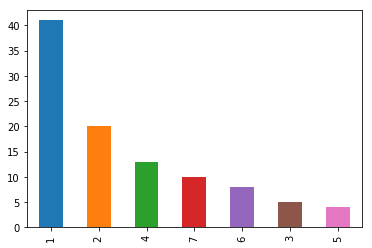

In [69]:
#Plot this, each class count
from matplotlib import pyplot as plot
%matplotlib inline
fig, ax = plot.subplots()
(labels.value_counts()).plot(ax=ax, kind='bar')

 > Group with class value=1 is more

In [70]:
# Here assuming 16 feature means, 16 columns as datapoints considered
#Use the 16-intermediate feature and perform an agglomerative clustering.
zoodata.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [71]:
#X = zoodata.iloc[:,1:].values
# Removing Class_type clolumn
X = zoodata.iloc[:,1:-1].values
print(X)
print(X.shape)
Y = zoodata.iloc[:,-1].values
Y

[[1 0 0 ... 0 0 1]
 [1 0 0 ... 1 0 1]
 [0 0 1 ... 1 0 0]
 ...
 [1 0 0 ... 1 0 1]
 [0 0 1 ... 0 0 0]
 [0 1 1 ... 1 0 0]]
(101, 16)


array([1, 1, 4, 1, 1, 1, 1, 4, 4, 1, 1, 2, 4, 7, 7, 7, 2, 1, 4, 1, 2, 2,
       1, 2, 6, 5, 5, 1, 1, 1, 6, 1, 1, 2, 4, 1, 1, 2, 4, 6, 6, 2, 6, 2,
       1, 1, 7, 1, 1, 1, 1, 6, 5, 7, 1, 1, 2, 2, 2, 2, 4, 4, 3, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 7, 4, 1, 1, 3, 7, 2, 2, 3, 7, 4, 2, 1, 7, 4, 2,
       6, 5, 3, 3, 4, 1, 1, 2, 1, 6, 1, 7, 2], dtype=int64)

## 3. Building Machine Learning - Agglomerative Cluster( Bottom Up algorithm)

### 3.1 Agglomerative with  affinity='euclidean', Linkage = 'ward'

In [72]:
 #Use the 16-intermediate feature and perform an agglomerative clustering.
from sklearn.cluster import AgglomerativeClustering
#hERE no of distinct unique 0/p value considered as n_clusters

cluster = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='ward')  
cluster.fit_predict(X)  
cluster.labels_   #After agglomerative algorithm labels/o/p
#This is the label of the datapoint, which are cluster id's

array([1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 3, 2, 6, 7, 7, 3, 1, 2, 2, 3, 3,
       1, 3, 0, 5, 5, 4, 1, 4, 0, 1, 4, 3, 2, 1, 1, 3, 2, 0, 0, 3, 0, 3,
       1, 1, 7, 1, 1, 1, 1, 0, 5, 0, 1, 1, 3, 3, 3, 3, 2, 2, 6, 5, 1, 1,
       2, 1, 1, 1, 1, 3, 0, 2, 2, 4, 6, 6, 3, 3, 6, 6, 2, 3, 4, 7, 2, 3,
       0, 5, 5, 5, 2, 4, 1, 3, 4, 0, 1, 6, 3], dtype=int64)

In [73]:
print(np.unique(Y))
print(np.unique(cluster.labels_))

[1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


- Here Y value starts from 1, so convert this to Y-1

In [74]:
Y_1 = Y-1
print(np.unique(Y_1))

[0 1 2 3 4 5 6]


In [75]:
##Compute the mean squared error by comparing the actual class and predicted high level class.
from sklearn import metrics
#Print Mean Squared Error MSE
print("MSE :" , metrics.mean_squared_error(Y_1,cluster.labels_))
print("accuracy score :" , metrics.accuracy_score(Y_1,cluster.labels_))
score = mean_squared_error(Y_1,model.labels_)
abs_error = np.sqrt(score)
print("RMSE score :" , np.sqrt(score))


MSE : 6.118811881188119
accuracy score : 0.039603960396039604
RMSE score : 2.4373333911071624



### 3.2 Agglomerative with  affinity='euclidean', Linkage = 'complete' 

In [76]:
cluster = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='complete')  
cluster.fit_predict(X)  
Y_2 = Y-1  # Here Y value starts from 1, so convert this to Y-1
print(np.unique(Y_2))
print("MSE :" , metrics.mean_squared_error(Y_2,cluster.labels_))
print("accuracy score :" , metrics.accuracy_score(Y_2,cluster.labels_))
score = mean_squared_error(Y_2,model.labels_)
abs_error = np.sqrt(score)
print("RMSE score :" , np.sqrt(score))


[0 1 2 3 4 5 6]
MSE : 3.5643564356435644
accuracy score : 0.42574257425742573
RMSE score : 2.4373333911071624



### 3.3 Agglomerative with  affinity='euclidean', linkage='average'

In [77]:
cluster = AgglomerativeClustering(n_clusters=8, affinity='euclidean', linkage='average')  
cluster.fit_predict(X)  
Y_3 = Y-1 # Here Y value starts from 1, so convert this to Y-1
print("MSE :" , metrics.mean_squared_error(Y_3,cluster.labels_))
print("accuracy score :" , metrics.accuracy_score(Y_3,cluster.labels_))
score = mean_squared_error(Y_3,model.labels_)
abs_error = np.sqrt(score)
print("RMSE score :" , np.sqrt(score))


MSE : 5.792079207920792
accuracy score : 0.37623762376237624
RMSE score : 2.4373333911071624



### 3.4 Agglomerative with  affinity='manhattan', linkage='average'

In [78]:
cluster = AgglomerativeClustering(n_clusters=8, affinity='manhattan', linkage='average')  
cluster.fit_predict(X)  
Y_4 = Y-1 # Here Y value starts from 1, so convert this to Y-1
print("MSE :" , metrics.mean_squared_error(Y_4,cluster.labels_))
print("accuracy score :" , metrics.accuracy_score(Y_4,cluster.labels_))
score = mean_squared_error(Y_4,model.labels_)
abs_error = np.sqrt(score)
print("RMSE score :" , np.sqrt(score))


MSE : 10.643564356435643
accuracy score : 0.0891089108910891
RMSE score : 2.4373333911071624



### 3.5 Agglomerative with   affinity='cosine', linkage='average'


In [79]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

model = AgglomerativeClustering(n_clusters=7,
                                    linkage="average", affinity="cosine")

model.fit(X)
model.labels_
Y_5 = Y-1 # Here Y value starts from 1, so convert this to Y-1
print("MSE :" , metrics.mean_squared_error(Y_5,model.labels_))
print("accuracy score :" , metrics.accuracy_score(Y_5,model.labels_))

score = mean_squared_error(Y_5,model.labels_)
abs_error = np.sqrt(score)
print("RMSE score :" , np.sqrt(score))


MSE : 5.9405940594059405
accuracy score : 0.38613861386138615
RMSE score : 2.4373333911071624


In [83]:
ds = pd.DataFrame(Y_5,model.labels_)
ds
# Most of the value are not matching to existing High level class

,0
0,0
0,0
1,3
0,0
0,0
0,0
0,0
1,3
1,3
0,0


## 5. CONCLUSION

- Agglomerative with  affinity='euclidean', Linkage = 'complete'   having MSE  less compared to other linkage
-MSE : 3.5643564356435644

- Here multiple input feature considered not 2, so we didnt plot in graph like other problems